# Adaptive Recovery Algorithm 
**March 2026**
- Extend to 2 qubits system

**April 2026**
Here we implement the updated adaptive recovery protocol, where the system's state collapses due to the measurement outcome on the ancilla.

## Fixed Choices
- `N qubits`: 1
- `Noises`: Amplitude Damping (50\%) / Dephasing (50\%)



In [42]:
using Pkg
Pkg.activate("../julia")
Pkg.instantiate()

  Activating project at `~/UNIPA/COLLISION_MODELS/shooting-decoherences/julia`


In [43]:
using LinearAlgebra
using Plots
using Revise
using JSON
using Latexify

using Random
using StatsBase

using Printf

# ==============================================
# Custom logger
using Logging, TerminalLoggers, ProgressLogging
# Display debug messages
global_logger(TerminalLogger(stderr, Logging.Info))
debuglogger = ConsoleLogger(stderr, Logging.Debug)

includet("../julia/src/logging.jl")
# ==============================================

includet("../julia/src/UnitaryDilation/UnitaryDilation.jl")
includet("../julia/src/PetzMaps.jl")
# includet("../julia/src/DecoKiller.jl")
includet("../julia/src/utils.jl")
includet("../julia/src/configurations.jl")
includet("../julia/src/custom_plots.jl")
includet("../julia/src/quantum_states.jl")

using .UnitaryDilation
# using .DecoKiller
using .PetzMaps

In [44]:
function apply_noise(model, ρ, n_qubits)
  ρf = apply_channel(model.kraus_fwd, ρ, n_qubits)
  # Enforce physicality (hermitianicity and trace 1)
  # enforce_physical!(ρf)
  return ρf
end


function recovery(model, ρ)
  ρr, η = apply_collision(model, ρ)
  # enforce_physical!(ρr)
  return ρr, η
end

recovery (generic function with 1 method)

## Setup

In [45]:
n_qubits = 2
beta = 3.0
gamma = 1.0
dt = 0.1
n_steps = 2

recovery_type = "auto"  # 'auto', 'random', 'codespace', 'inputspace'

fidelities = Float64[]
fidelities_ref = Float64[]  # Store the fidelities of the noisy state evolving without recovery

# Random but reproducible states
seed = 42
rng = Xoshiro(seed)

Xoshiro(0xa379de7eeeb2a4e8, 0x953dccb6b532b3af, 0xf597b8ff8cfd652a, 0xccd7337c571680d1, 0xc90c4a0730db3f7e)

### Initial States
We create the recovery state `sigma` and a random initial state

In [78]:
# Choose a reference state for the recovery
# sigma = thermal_state(n_qubits, beta)
sigma = codespace_dm(n_qubits, 0.6, 0.4)
ρ0 = copy(sigma)  # Default to the thermal state, but will be overwritten based on recovery_type

if recovery_type == "random"
    ψ = random_state(n_qubits)
    ρ0 = ψ * ψ'
elseif recovery_type == "auto"
    ρ0 = copy(sigma)
elseif recovery_type == "codespace"
    p = rand()
    max_x = p * (1-p)  # Maximum allowed magnitude for |x|^2
    radius = sqrt(rand() * max_x)
    x = radius * exp(2π * im * rand())
    ρ = codespace_dm(n_qubits, p, x)
    ρ0 = ρ + sigma
    ρ0 = ρ0 / tr(ρ0)  # Normalize to ensure it's a valid density matrix
elseif recovery_type == "inputstate"
    a, b = rand(rng, 2)
    ψ = input_state(n_qubits, a, b)
    ρ0 = ψ * ψ'
end

display(latexify(sigma; fmt="%.3f")) # display as LaTeX table
display(latexify(ρ0; fmt="%.3f"))

L"\begin{equation}
\left[
\begin{array}{cccc}
0.600+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.400+0.000\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.400+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.400+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.600+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.400+0.000\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.400+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.400+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

### Noise

In [79]:
noise_probabilities = [
  (0.50, "amplitude_damping"),
  (0.50, "phase_damping"),
]

# ======================================
# Precompute the supermaps once
noise_options = [
  NoiseObj(noise_model[2], noise_model[1], sigma, gamma, dt)
  for noise_model in noise_probabilities
]

# ======================================
# Fix the real Noise model
noise = "amplitude_damping"
println("Chosen noise:\t\t$noise")
real_noise_idx = findfirst(n -> n.name == noise, noise_options)
real_noise = noise_options[real_noise_idx]
# Take the relevant Kraus operators
real_kraus = get_kraus_operators(noise, gamma, dt)
real_model = CollisionModel(real_kraus, sigma, n=n_qubits)

Chosen noise:		amplitude_damping


CollisionModel{ComplexF64}(4, 4, ComplexF64[0.6 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.4 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.4 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.4 + 0.0im], Matrix{ComplexF64}[[1.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.951229424500714 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.951229424500714 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.9048374180359596 + 0.0im], [0.0 + 0.0im 0.0 + 0.0im 0.3084843301758462 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.29343937186065844 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im], [0.0 + 0.0im 0.3084843301758462 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.29343937186065844 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im], [0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.09

In [80]:
kraus_to_superop(noise_options[1].kraus)

4×4 Matrix{ComplexF64}:
 1.0+0.0im       0.0+0.0im       0.0+0.0im  0.0951626+0.0im
 0.0+0.0im  0.951229+0.0im       0.0+0.0im        0.0+0.0im
 0.0+0.0im       0.0+0.0im  0.951229+0.0im        0.0+0.0im
 0.0+0.0im       0.0+0.0im       0.0+0.0im   0.904837+0.0im

In [81]:
model = CollisionModel(noise_options[1].kraus, sigma, n=n_qubits)
model.kraus_fwd
_, M_noise = build_superoperators(model)
M_noise

16×16 Matrix{ComplexF64}:
 1.0+0.0im       0.0+0.0im  …        0.0+0.0im  0.00905592+0.0im
 0.0+0.0im  0.951229+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im     0.0905214+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im  …        0.0+0.0im   0.0861067+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im  …        0.0+0.0im   0.0861067+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im      0.860708+0.0im         0.0+0.0im

### Initialization

In [82]:

config = RecoveryConfig(
    "notebook", # name of the experiment
    "../experiments/example",
    sigma,      # reference state
    "auto",     # recovery type
    real_noise,
    n_qubits,
    n_steps,
    1,          # number of states
    seed,
    rng,
    dt,
    0.8
)


rho0, rho_to_rec, rho_free = copy(ρ0), copy(ρ0), copy(ρ0)

# Make a random choice (see configurations.jl for details)
choice = make_initial_choice(rng, noise_options)

noise_guess = deepcopy(noise_options[choice.current])
M_total = noise_guess.supermap_noise

println("Initial noise guess:\t$(noise_guess.name)")
println("Size of superoperator:\t$(size(M_total))")

state = RecoveryState(
    rho0, rho_to_rec, rho_free, noise_guess, M_total, choice, noise_options)

logs = RecoveryLogs()

Initial noise guess:	amplitude_damping
Size of superoperator:	(16, 16)


RecoveryLogs(Float64[], Float64[], Int64[], @NamedTuple{Nx::Matrix{ComplexF64}, N1::Matrix{ComplexF64}, N2::Matrix{ComplexF64}, P::Matrix{ComplexF64}}[])

In [83]:
# Rename variables for readability
Ox = config.real_noise.supermap_noise
O1 = state.noise_options[1].supermap_noise
O2 = state.noise_options[2].supermap_noise
Nx = config.real_noise.supermap
N1 = state.noise_options[1].supermap
N2 = state.noise_options[2].supermap
;

In [84]:
state.noise_options[1].supermap_noise

16×16 Matrix{ComplexF64}:
 1.0+0.0im       0.0+0.0im  …        0.0+0.0im  0.00905592+0.0im
 0.0+0.0im  0.951229+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im     0.0905214+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im  …        0.0+0.0im   0.0861067+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im  …        0.0+0.0im   0.0861067+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im      0.860708+0.0im         0.0+0.0im

In [85]:
state.noise_options[1].supermap

16×16 Matrix{ComplexF64}:
 1.0+0.0im       0.0+0.0im  …        0.0+0.0im  0.00905592+0.0im
 0.0+0.0im  0.951229+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im     0.0905214+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im  …        0.0+0.0im   0.0861067+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im  …        0.0+0.0im   0.0861067+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im           0.0+0.0im         0.0+0.0im
 0.0+0.0im       0.0+0.0im      0.860708+0.0im         0.0+0.0im

## Algorithm

### Step 1: Initial Noise
We apply the unknown **real noise**.
- `rho_free`: control state where only noise is applied
- `rho_rec`: state to recover, where noise + collision are applied
- `rho1`: keep track of what should happen if noise 1 were present
- `rho2`: keep track of what should happen if noise 1 were present

We keep the variable `rho2_` as intermediate state after the noise but before the recovery.

This will be used to test ancilla outputs given a known noise.


In [86]:
rho_free = unvec(Nx * vec(state.ρ0))
rho_to_rec = unvec(Nx * vec(state.ρ0))
rho1 = unvec(N1 * vec(state.ρ0))
rho2 = unvec(N2 * vec(state.ρ0))
# rho_free = unvec(Nx * vec(state.ρ0))
# rho1 = copy(rho_to_rec)
# rho2 = copy(rho_to_rec)

println("Fidelity after noise: ", fidelity(state.ρ0, rho_to_rec))
display(latexify(rho_to_rec; fmt="%.3f"))

Fidelity after noise: 0.9287974791692014


L"\begin{equation}
\left[
\begin{array}{cccc}
0.604+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.362+0.000\mathit{i} \\
0.0\mathit{i} & 0.034+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.034+0.000\mathit{i} & 0.0\mathit{i} \\
0.362+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.327+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

### Step 2.1: Informative Collision
We let the state `rho_rec` (and `rho1`, `rho2` for tracking) interact with an ancilla with a Unitary SWAP interaction map,
$$
U_{\text{SWAP}}|a\rangle \otimes|b\rangle=|b\rangle\otimes|a\rangle
$$

Here we also start from a not-pure ancilla $\eta = p|0\rangle\langle 0| + (1-p)|1\rangle\langle 1|$

In [87]:
function embed_operator(op::Matrix, target_index::Int, n::Int)
    I2 = [1.0 0.0; 0.0 1.0] # 2x2 Identity
    
    # Start the Kronecker product chain
    result = (target_index == 1) ? op : I2
    for i in 2:n
        next_op = (i == target_index) ? op : I2
        result = kron(result, next_op)
    end
    return result
end

function n_qubit_exchange_unitary(n_qubits::Int, g::Float64=0.1, t::Float64=1.0)
  # Qubit raising and lowering operators
  sp = [0.0 1.0; 0.0 0.0]
  sm = [0.0 0.0; 1.0 0.0]

  # Total dimension, considering 1 qubit ancilla
  n_total = n_qubits + 1
  d = 2^(n_total)
  H_int = zeros(ComplexF64, d, d)

  # The ancilla is the 'last system' in the kronecker product
  ancilla_idx = n_total
  sp_anc = embed_operator(sp, ancilla_idx, n_total)
  sm_anc = embed_operator(sm, ancilla_idx, n_total)
    
  # Sum over all k system qubits
  for k in 1:n_qubits
      sp_k = embed_operator(sp, k, n_total)
      sm_k = embed_operator(sm, k, n_total)
      
      exchange_term = (sp_anc * sm_k) + (sm_anc * sp_k)
      
      H_int += (g / n_qubits) * exchange_term
  end
  
  # Return the time evolution unitary U(t)
  U = exp(-1im * H_int * t)
  return U
end
 

U = n_qubit_exchange_unitary(n_qubits)
# Check the collision
η = ancilla_thermal_qubit(0.8)

display(ptrace_ancilla(U * kron(state.ρ0, η) * U', 2^n_qubits, 2))
display(ptrace_sys(U * kron(state.ρ0, η) * U', 2^n_qubits, 2))

4×4 Matrix{ComplexF64}:
 0.599401+0.0im         0.0+0.0im         0.0+0.0im     0.399+0.0im
      0.0+0.0im  0.00109817+0.0im  0.00109817+0.0im       0.0+0.0im
      0.0+0.0im  0.00109817+0.0im  0.00109817+0.0im       0.0+0.0im
    0.399+0.0im         0.0+0.0im         0.0+0.0im  0.398403+0.0im

2×2 Matrix{ComplexF64}:
 0.799002+0.0im       0.0+0.0im
      0.0+0.0im  0.200998+0.0im

The trail `_` in `rho_to_rec_`, `rho1_`, and `rho2_`, will indicate their entanglement with an ancilla.

In [88]:
kron(state.ρ0, η)

8×8 Matrix{ComplexF64}:
 0.48+0.0im   0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.32+0.0im   0.0+0.0im
  0.0+0.0im  0.12+0.0im  0.0+0.0im     0.0+0.0im   0.0+0.0im  0.08+0.0im
  0.0+0.0im   0.0+0.0im  0.0+0.0im     0.0+0.0im   0.0+0.0im   0.0+0.0im
  0.0+0.0im   0.0+0.0im  0.0+0.0im     0.0+0.0im   0.0+0.0im   0.0+0.0im
  0.0+0.0im   0.0+0.0im  0.0+0.0im     0.0+0.0im   0.0+0.0im   0.0+0.0im
  0.0+0.0im   0.0+0.0im  0.0+0.0im  …  0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.32+0.0im   0.0+0.0im  0.0+0.0im     0.0+0.0im  0.32+0.0im   0.0+0.0im
  0.0+0.0im  0.08+0.0im  0.0+0.0im     0.0+0.0im   0.0+0.0im  0.08+0.0im

In [89]:
model = CollisionModel(
    U, sigma, 2^n_qubits, 2, ancilla_state=η)

# Get the composite state system+ancilla
rho_to_rec_ = apply_collision(model, rho_to_rec; ancilla_state=η, trace=false)
rho1_ = apply_collision(model, rho1; ancilla_state=η, trace=false)
rho2_ = apply_collision(model, rho2; ancilla_state=η, trace=false)

8×8 Matrix{ComplexF64}:
     0.48+0.0im              0.0+0.0im         …        0.0+0.0im
      0.0+0.0im         0.119401+0.0im            0.0722061+0.0im
      0.0+0.0im              0.0-0.00598002im           0.0-0.00361633im
      0.0-0.0144653im        0.0+0.0im                  0.0+0.0im
      0.0+0.0im              0.0-0.00598002im           0.0-0.00361633im
      0.0-0.0144653im        0.0+0.0im         …        0.0+0.0im
 0.288824+0.0im              0.0+0.0im                  0.0+0.0im
      0.0+0.0im        0.0722061+0.0im                 0.08+0.0im

### Step 2.2: Disentangling Noise
We apply again the **real noise** only on the system. This reduces the shared correlations with the ancilla, and consequently the ''destructivness'' of the ancilla measurement

In [90]:
# This is equivalent to applying the supermap to the system alone,
#  extending the supermap to act as identity on the ancilla
rho_to_rec_ = apply_channel(config.real_noise.kraus, rho_to_rec_, n_qubits; extra_dims=size(η, 1))
rho1_ = apply_channel(config.real_noise.kraus, rho1_, n_qubits; extra_dims=size(η, 1))
rho2_ = apply_channel(config.real_noise.kraus, rho2_, n_qubits; extra_dims=size(η, 1))

8×8 Matrix{ComplexF64}:
  0.48294+0.0im              0.0+0.0im         …        0.0+0.0im
      0.0+0.0im         0.120277+0.0im            0.0653348+0.0im
      0.0+0.0im              0.0-0.00424485im           0.0-0.00311261im
      0.0-0.0134325im        0.0+0.0im                  0.0+0.0im
      0.0+0.0im              0.0-0.00424485im           0.0-0.00311261im
      0.0-0.0134325im        0.0+0.0im         …        0.0+0.0im
 0.261339+0.0im              0.0+0.0im                  0.0+0.0im
      0.0+0.0im        0.0653348+0.0im            0.0654985+0.0im

### Step 3.1: Measurement
We measure the output ancilla and compare it with the possible options, given the possible noises.
The measurement outcome may be 1 with probability `p1` or 2 with probability `p2`, where `p1` and `p2` are obtained for an optimal discrimination POVM.

In [91]:
η_test = ptrace_sys(rho_to_rec_, 2^n_qubits, 2)
η1 = ptrace_sys(rho1_, 2^n_qubits, 2)
η2 = ptrace_sys(rho2_, 2^n_qubits, 2)

display(latexify(η_test; fmt="%.3f"))
display(latexify(η1; fmt="%.3f"))
display(latexify(η2; fmt="%.3f"))

L"\begin{equation}
\left[
\begin{array}{cc}
0.799+0.000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.201+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
0.799+0.000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.201+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
0.799+0.000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.201+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

In [92]:
function discrimin(ρ_test, ρ1, ρ2, ds, da, q1::Real = 0.5, q2::Real = 0.5, tol=1e-10)
  # Check this is actually a bipartite state of the expected dimensions
  size(ρ_test) == (ds*da, ds*da) || error("ρ_test has incompatible dimensions")
  size(ρ1) == (ds*da, ds*da) || error("ρ1 has incompatible dimensions")
  size(ρ2) == (ds*da, ds*da) || error("ρ2 has incompatible dimensions")
  
  # Trace out the system to get the reduced states of the ancilla
  η_test = ptrace_sys(ρ_test, ds, da)
  η1 = ptrace_sys(ρ1, ds, da)
  η2 = ptrace_sys(ρ2, ds, da)

  Δη = q1 * η1 - q2 * η2

  # Early exit: states are indistinguishable, return uniform
  # if norm(Δη) < tol
  #     return [0.5, 0.5]
  # end

  eigen_decomp = eigen(Hermitian(Δη))
  eigenvalues  = eigen_decomp.values
  eigenvectors = eigen_decomp.vectors

  Π1 = zeros(ComplexF64, da, da)
  for i in eachindex(eigenvalues)
      if eigenvalues[i] > tol
          v   = eigenvectors[:, i]
          Π1 += v * v'
      end
  end
  Π2 = I(da) - Π1

  p1 = real(tr(Π1 * η_test))
  p2 = real(tr(Π2 * η_test))

  # Numerical sanity: p1 + p2 should be 1
  total = p1 + p2
  return [p1/total, p2/total], [Π1, Π2]
end

# ancillas must be normalized with the probabilities of their respective noise channels
q1 = state.noise_options[1].probability
q2 = state.noise_options[2].probability
w, Πs = discrimin(rho_to_rec_, rho1_, rho2_, 2^n_qubits, 2, q1, q2);
println("Probabilities of the POVM outputs: $w")

povm = sample(rng, [1, 2], Weights(w))
println("Measurement result: $povm")

Probabilities of the POVM outputs: [0.7991916737226707, 0.20080832627732922]
Measurement result: 1


In [93]:
display(latexify(Πs[1]; fmt="%.3f"))
display(latexify(Πs[2]; fmt="%.3f"))

L"\begin{equation}
\left[
\begin{array}{cc}
1.000+0.000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cc}
-0.0\mathit{i} & -0.0\mathit{i} \\
-0.0\mathit{i} & 1.000+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

### Step 3.2: Collapse
Given one measurement outcome on the ancilla, the system collapses in the relative state.

In [94]:
function collapse_state(ρ_SA, Π)
  da = size(Π, 1)
  ds = size(ρ_SA, 1) ÷ da
  # Measurement operator: M = I ⊗ Π
  M = kron(I(ds), Π)
  ρ_post = M * ρ_SA * M'
  Z = real(tr(ρ_post))  # Normalization factor
  # Regularization constant to avoid division by zero in pathological cases
  ε = 1e-12
  Z = max(Z, ε)
  return ρ_post / Z
end

collapsed_rho_to_rec = collapse_state(rho_to_rec_, Πs[povm])
collapsed_rho1 = collapse_state(rho1_, Πs[povm])
collapsed_rho2 = collapse_state(rho2_, Πs[povm])

rho_to_rec = ptrace_ancilla(collapsed_rho_to_rec, 2^n_qubits, size(η, 1))
rho1 = ptrace_ancilla(collapsed_rho1, 2^n_qubits, size(η, 1))
rho2 = ptrace_ancilla(collapsed_rho2, 2^n_qubits, size(η, 1))

4×4 Matrix{ComplexF64}:
  0.60443+0.0im          0.0+0.0im          0.0+0.0im  0.327082+0.0im
      0.0+0.0im    0.0346527+0.0im  0.000339172+0.0im       0.0+0.0im
      0.0+0.0im  0.000339172+0.0im    0.0346527+0.0im       0.0+0.0im
 0.327082+0.0im          0.0+0.0im          0.0+0.0im  0.326265+0.0im

In [95]:
display(latexify(rho_to_rec_; fmt="%.3f"))
display(latexify(rho1_; fmt="%.3f"))
display(latexify(rho2_; fmt="%.3f"))

display(latexify(collapsed_rho_to_rec; fmt="%.5f"))
display(latexify(collapsed_rho1; fmt="%.5f"))
display(latexify(collapsed_rho2; fmt="%.5f"))

display(latexify(rho_to_rec; fmt="%.3f"))
display(latexify(rho1; fmt="%.3f"))
display(latexify(rho2; fmt="%.3f"))

"\\begin{equation}\n\\left[\n\\begin{array}{cccccccc}\n0.491+0.000\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.01343249856744902\\mathit{i} & 0.0\\mathit{i} & 0.01343249856744902\\mathit{i} & 0.261+0.000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.122+0.000\\mathit{i} & 0.0032657" ⋯ 978 bytes ⋯ "22449\\mathit{i} & 0.213+0.000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.065+0.000\\mathit{i} & 0.0031126077785987773\\mathit{i} & 0.0\\mathit{i} & 0.0031126077785987773\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.054+0.000\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

"\\begin{equation}\n\\left[\n\\begin{array}{cccccccc}\n0.491+0.000\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.01343249856744902\\mathit{i} & 0.0\\mathit{i} & 0.01343249856744902\\mathit{i} & 0.261+0.000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.122+0.000\\mathit{i} & 0.0032657" ⋯ 978 bytes ⋯ "22449\\mathit{i} & 0.213+0.000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.065+0.000\\mathit{i} & 0.0031126077785987773\\mathit{i} & 0.0\\mathit{i} & 0.0031126077785987773\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.054+0.000\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

"\\begin{equation}\n\\left[\n\\begin{array}{cccccccc}\n0.483+0.000\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.01343249856744902\\mathit{i} & 0.0\\mathit{i} & 0.01343249856744902\\mathit{i} & 0.261+0.000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.120+0.000\\mathit{i} & 0.0042448" ⋯ 970 bytes ⋯ "96382\\mathit{i} & 0.261+0.000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.065+0.000\\mathit{i} & 0.0031126077785987773\\mathit{i} & 0.0\\mathit{i} & 0.0031126077785987773\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.065+0.000\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

"\\begin{equation}\n\\left[\n\\begin{array}{cccccccc}\n0.61380+0.00000\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.32700+0.00000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathi" ⋯ 662 bytes ⋯ "& 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.26709+0.00000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

"\\begin{equation}\n\\left[\n\\begin{array}{cccccccc}\n0.61380+0.00000\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.32700+0.00000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathi" ⋯ 662 bytes ⋯ "& 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.26709+0.00000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

"\\begin{equation}\n\\left[\n\\begin{array}{cccccccc}\n0.60443+0.00000\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.32708+0.00000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathi" ⋯ 662 bytes ⋯ "& 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.32626+0.00000\\mathit{i} & 0.0\\mathit{i} \\\\\n0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} & 0.0\\mathit{i} \\\\\n\\end{array}\n\\right]\n\\end{equation}\n"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.614+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.327+0.000\mathit{i} \\
0.0\mathit{i} & 0.060+0.000\mathit{i} & 0.000+0.000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.000+0.000\mathit{i} & 0.060+0.000\mathit{i} & 0.0\mathit{i} \\
0.327+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.267+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.614+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.327+0.000\mathit{i} \\
0.0\mathit{i} & 0.060+0.000\mathit{i} & 0.000+0.000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.000+0.000\mathit{i} & 0.060+0.000\mathit{i} & 0.0\mathit{i} \\
0.327+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.267+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.604+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.327+0.000\mathit{i} \\
0.0\mathit{i} & 0.035+0.000\mathit{i} & 0.000+0.000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.000+0.000\mathit{i} & 0.035+0.000\mathit{i} & 0.0\mathit{i} \\
0.327+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.326+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

### Step 3.3: Complete the Map
To be able to recover the state from this perturbation, we create a CPTP map such that its output is the same as the measurement collapse.

In [96]:
function create_transfer_kraus(d, p, q)
  ks = Matrix{ComplexF64}[]
  if d == 2
    p1, p2 = p
    q1, q2 = q

    # Initialize trivial operators for edge cases
    k0 = Matrix{ComplexF64}(I, 2, 2)
    k1 = zeros(ComplexF64, 2, 2)

    if q1 < p1
      k0 = [sqrt(q1/p1) 0; 0 1]
      k1 = [0 0; sqrt(1-q1/p1) 0]
    elseif q2 > p2
      k0 = [1 0; 0 sqrt(p2/q2)]
      k1 = [0 sqrt(1-p2/q2); 0 0]
    end
    ks = [k0, k1]
  elseif d == 4
    alpha = min(p[1]*q[1], p[2]*q[2])
    beta = min(p[3]*q[3], p[4]*q[4])
    # Decrease alpha and beta
    alpha = alpha / 10.0
    beta = beta / 10.0
    @debug "ps: $(p), qs: $(q), alpha: $(alpha), beta: $(beta)"
    # K0: Main diagonal (k=0)
    K0 = diagm(0 => [
        sqrt((p[1]*q[1] - alpha) / p[1]),
        sqrt((p[2]*q[2] - alpha) / p[2]),
        sqrt((p[3]*q[3] - beta) / p[3]),
        sqrt((p[4]*q[4] - beta) / p[4])
    ])

    # K1: First super-diagonal (k=1)
    K1 = diagm(1 => [
        sqrt((p[2]*q[1] + alpha) / p[2]),
        sqrt((p[3]*q[2]) / p[3]),
        sqrt((p[4]*q[3] + beta) / p[4])
    ])

    # K2: First sub-diagonal (k=-1)
    K2 = diagm(-1 => [
        sqrt((p[1]*q[2] + alpha) / p[1]),
        sqrt((p[2]*q[3]) / p[2]),
        sqrt((p[3]*q[4] + beta) / p[3])
    ])

    # K3: Second super-diagonal (k=2)
    K3 = diagm(2 => [
        sqrt((p[3]*q[1]) / p[3]),
        sqrt((p[4]*q[2]) / p[4])
    ])

    # K4: Second sub-diagonal (k=-2)
    K4 = diagm(-2 => [
        sqrt((p[1]*q[3]) / p[1]),
        sqrt((p[2]*q[4]) / p[2])
    ])

    # K5: Third super-diagonal (k=3)
    K5 = diagm(3 => [
        sqrt((p[4]*q[1]) / p[4])
    ])

    # K6: Third sub-diagonal (k=-3)
    K6 = diagm(-3 => [
        sqrt((p[1]*q[4]) / p[1])
    ])

    ks = [K0, K1, K2, K3, K4, K5, K6]

  end

  return ks
end

function collapse_map(input_state, output_state)
  d = size(input_state, 1)

  function clean_eigenvalues(eigvals, tol=1e-10)
    cleaned = similar(eigvals)
    for i in eachindex(eigvals)
        val = real(eigvals[i])
        if abs(val) < tol
            cleaned[i] = 0.0
        elseif val < 0
            cleaned[i] = 0.0
        else
            cleaned[i] = val
        end
    end
    return cleaned
  end
  
  function stochastic_projection(states_in, states_out)
    # projectors = [states_out[:, i] * states_in[:, i]' for i in 1:length(states_in)]
    # return sum(projectors)
    return states_out * states_in'
  end

  eigen_decomp = eigen(Hermitian(input_state), sortby = x -> -real(x))
  p            = clean_eigenvalues(eigen_decomp.values)
  phi_in       = eigen_decomp.vectors

  eigen_decomp = eigen(Hermitian(output_state), sortby = x -> -real(x))
  q            = clean_eigenvalues(eigen_decomp.values)
  phi_out      = eigen_decomp.vectors

  basis = Matrix{ComplexF64}(I, d, d)

  U1 = stochastic_projection(phi_in, basis)
  superopU1 = kron(conj(U1), U1)

  K_transfer = create_transfer_kraus(d, p, q)
  superopK = kraus_to_superop(K_transfer)

  U2 = stochastic_projection(basis, phi_out)
  superopU2 = kron(conj(U2), U2)

  return superopU2 * superopK * superopU1
end

Cx = collapse_map(ptrace_ancilla(rho_to_rec_, 2^n_qubits, size(η, 1)), rho_to_rec)
C1 = collapse_map(ptrace_ancilla(rho1_, 2^n_qubits, size(η, 1)), rho1)
C2 = collapse_map(ptrace_ancilla(rho2_, 2^n_qubits, size(η, 1)), rho2)

16×16 Matrix{ComplexF64}:
    0.725944+0.0im     0.0543155+0.0im  …      0.48664+0.0im
   0.0112112+0.0im     0.0723038+0.0im      -0.0112112+0.0im
   0.0112112+0.0im     -0.025397+0.0im      -0.0112112+0.0im
    0.277939+0.0im    -0.0821182+0.0im        0.384985+0.0im
   0.0112112+0.0im    2.2204e-18+0.0im      -0.0112112+0.0im
   0.0187019+0.0im    -0.0070762+0.0im  …    0.0506036+0.0im
 0.000339172+0.0im     0.0070762+0.0im     0.000339172+0.0im
    -0.01695+0.0im  -2.15816e-18+0.0im         0.01695+0.0im
   0.0112112+0.0im  -5.00791e-18+0.0im      -0.0112112+0.0im
 0.000339172+0.0im    -0.0070762+0.0im     0.000339172+0.0im
   0.0506036+0.0im     0.0070762+0.0im  …    0.0187019+0.0im
    -0.01695+0.0im   8.77014e-18+0.0im         0.01695+0.0im
    0.277939+0.0im     0.0359259+0.0im        0.384985+0.0im
    -0.01695+0.0im     0.0433112+0.0im         0.01695+0.0im
    -0.01695+0.0im    -0.0493831+0.0im         0.01695+0.0im
     0.20475+0.0im    -0.0543155+0.0im  …     0.444054+0.0i

In [97]:
# Proof
before_collapse = ptrace_ancilla(rho_to_rec_, 2^n_qubits, size(η, 1))
display(before_collapse)
after_collapse = rho_to_rec

state_to_check = unvec(Cx * vec(before_collapse))
norm(state_to_check - after_collapse) < 1e-12

4×4 Matrix{ComplexF64}:
 0.612832+0.0im         0.0+0.0im         0.0+0.0im  0.326674+0.0im
      0.0+0.0im   0.0600412+0.0im  0.00078652+0.0im       0.0+0.0im
      0.0+0.0im  0.00078652+0.0im   0.0600412+0.0im       0.0+0.0im
 0.326674+0.0im         0.0+0.0im         0.0+0.0im  0.267085+0.0im

true

### Step 3.4: Update the Noise map
To recover all the previous perturbations, we must transform all the maps to one combined supermap,
$$
\mathcal{N} = \Lambda_{\text{complt}} \circ \Xi \circ \mathcal{N}\,,
$$
with 
$$
\Xi[\rho] = \text{Tr}_A\left[ (\Omega\otimes\mathbb{I}) U_{SA}(\rho\otimes\eta)U_{SA}^\dagger \right]
$$
This can be done composing the Kraus map for the noise and that for a system+ancilla unitary:
$$
\Omega[X]=\sum_m M_m X M^\dagger_m\,
$$
and, diagonalizing the ancilla as $\sum p_n|n\rangle \langle n|$,
$$
K_{i,n}​=\sqrt{p_n}​(\mathbb{I}_S\otimes\langle i|)U(\mathbb{I}_S\otimes|n\rangle)\,,
$$
so that the effective Kraus operators become:
$$
K_{m,i,n} = M_m\sqrt{p_n}​(\mathbb{I}_S\otimes\langle i|)U(\mathbb{I}_S\otimes|n\rangle)\,,
$$
and finally the supermap:
$$
S_\Xi=\sum_{m,i,n} = K^*_{m,i,n}\otimes K_{m,i,n}
$$

In [98]:
model.kraus_fwd[1]
config.real_noise.kraus[1]

2×2 Matrix{ComplexF64}:
 1.0+0.0im       0.0+0.0im
 0.0+0.0im  0.951229+0.0im

In [99]:
function compose_kraus(
    kraus2::Vector{<:AbstractMatrix},
    kraus1::Vector{<:AbstractMatrix},
)
    # channel 1 first, then channel 2
    out = Matrix{eltype(kraus1[1])}[]
    for K2 in kraus2
        for K1 in kraus1
            push!(out, K2 * K1)
        end
    end
    return out
end

real_system_kraus = config.real_noise.extended_kraus
option_system_kraus = [noise.extended_kraus for noise in state.noise_options]

Xi = kraus_to_superop(
    compose_kraus(real_system_kraus, model.kraus_fwd))
Xi1 = kraus_to_superop(
    compose_kraus(option_system_kraus[1], model.kraus_fwd))
Xi2 = kraus_to_superop(
    compose_kraus(option_system_kraus[2], model.kraus_fwd))


16×16 Matrix{ComplexF64}:
    0.999002+0.0im          0.0+0.0im  …          0.0+0.0im         0.0+0.0im
         0.0+0.0im     0.949566+0.0im             0.0+0.0im         0.0+0.0im
         0.0+0.0im  -0.00118795+0.0im             0.0+0.0im         0.0+0.0im
         0.0+0.0im          0.0+0.0im             0.0+0.0im         0.0+0.0im
         0.0+0.0im          0.0+0.0im      0.00189929+0.0im         0.0+0.0im
 0.000499167+0.0im          0.0+0.0im  …          0.0+0.0im  0.00199667+0.0im
 0.000451665+0.0im          0.0+0.0im             0.0+0.0im  0.00180666+0.0im
         0.0+0.0im  0.000474823+0.0im             0.0+0.0im         0.0+0.0im
         0.0+0.0im          0.0+0.0im      0.00189929+0.0im         0.0+0.0im
 0.000451665+0.0im          0.0+0.0im             0.0+0.0im  0.00180666+0.0im
 0.000499167+0.0im          0.0+0.0im  …          0.0+0.0im  0.00199667+0.0im
         0.0+0.0im  0.000474823+0.0im             0.0+0.0im         0.0+0.0im
         0.0+0.0im          0.0+0.0im 

In [100]:
# Check that this supermap reproduces the collision + noise
before_collapse = ptrace_ancilla(rho_to_rec_, 2^n_qubits, size(η, 1))
isapprox(unvec(Xi * Nx * vec(state.ρ0)), before_collapse)

true

In [101]:
# Update the supermaps in the config and state
config.real_noise.supermap = Cx * Xi * Nx
state.noise_options[1].supermap = C1 * Xi1 * N1
state.noise_options[2].supermap = C2 * Xi2 * N2

N1 = state.noise_options[1].supermap
N2 = state.noise_options[2].supermap

16×16 Matrix{ComplexF64}:
    0.725823+0.0im    0.0489253+0.0im  …     0.487111+0.0im
      0.0112+0.0im    0.0652781+0.0im      -0.0111665+0.0im
      0.0112+0.0im   -0.0231483+0.0im      -0.0111665+0.0im
    0.277988+0.0im   -0.0741299+0.0im        0.384753+0.0im
      0.0112+0.0im   1.30024e-5+0.0im      -0.0111665+0.0im
   0.0187178+0.0im  -0.00637396+0.0im  …    0.0505399+0.0im
 0.000336251+0.0im   0.00639327+0.0im     0.000327488+0.0im
   -0.016933+0.0im   5.32428e-5+0.0im       0.0168823+0.0im
      0.0112+0.0im   3.07985e-5+0.0im      -0.0111665+0.0im
 0.000336251+0.0im  -0.00639327+0.0im     0.000327488+0.0im
   0.0505876+0.0im   0.00637396+0.0im  …    0.0187656+0.0im
   -0.016933+0.0im   2.63373e-5+0.0im       0.0168823+0.0im
    0.277988+0.0im    0.0325217+0.0im        0.384753+0.0im
   -0.016933+0.0im    0.0390646+0.0im       0.0168823+0.0im
   -0.016933+0.0im   -0.0446651+0.0im       0.0168823+0.0im
    0.204872+0.0im   -0.0489253+0.0im  …     0.443584+0.0im

### Step 4: Choose the Noise
Based on the information extracted with the informative collision, choose a supermap to recover among `N1` and `N2`.

In [102]:
function update_noise_guess!(state, povm; inertia::Int=1)

  # update the count of noise choices
  if povm == 1
    append!(state.choice.c1, 1)
    append!(state.choice.c2, 0)
    state.choice.c1_count += 1
  elseif povm == 2
    append!(state.choice.c1, 0)
    append!(state.choice.c2, 1)
    state.choice.c2_count += 1
  end

  # Always choose the leading accumulated povm
  if state.choice.c1_count > state.choice.c2_count
    state.choice.current = 1
  elseif state.choice.c2_count > state.choice.c1_count
    state.choice.current = 2
  else
    # Look at the previous choices to break ties
    state.choice.current = state.choice.history[end]
  end

  append!(state.choice.history, state.choice.current)
end

update_noise_guess!(state, povm)
new_guess = state.noise_options[state.choice.current]
println("Updated noise guess:\t$(new_guess.name)")

Updated noise guess:	amplitude_damping


### Step 5: Recovery

In [103]:
model = CollisionModel(state.choice.current == 1 ? C1 * Xi1 * N1 : C2 * Xi2 * N2, config.sigma)
P = kraus_to_superop(model.kraus_rec);

# Get the state state recovered by the Stinespring dilation of the Petz map
rho_rec, _ = apply_collision(model, rho_to_rec; trace=true)
model1 = CollisionModel(C1 * Xi1 * N1, config.sigma)
rho1, _ = apply_collision(model1, rho1; trace=true)
model2 = CollisionModel(C2 * Xi2 * N2, config.sigma)
rho2, _ = apply_collision(model2, rho2; trace=true)
;

### Step 6: Measure Fidelity

In [104]:
fid_initial = fidelity(state.ρ0, rho_rec)
fid_track = fidelity(state.ρ0, rho_free)

println("Fidelity after recovery: ", fid_initial)
println("Fidelity without recovery: ", fid_track)

Fidelity after recovery: 0.9999988621115095
Fidelity without recovery: 0.9287974791692014


---

## Iterate
Update the complete map. 
This requires using the supermap operators and multiplying them

In [105]:
function iterate_recovery(
  step::Int, state::RecoveryState, config::RecoveryConfig, logs::RecoveryLogs
  )
  
  # Rename variables for readability
  Ox = config.real_noise.supermap_noise
  O1 = state.noise_options[1].supermap_noise
  O2 = state.noise_options[2].supermap_noise
  Nx = config.real_noise.supermap
  N1 = state.noise_options[1].supermap
  N2 = state.noise_options[2].supermap
  
  ds = 2^config.n_qubits
  da = size(config.ancilla_state, 1)

  # ======================================
  # Step 1: Initial Noise
  rho_free = unvec((Ox)^step * vec(state.ρ0))
  rho_to_rec = unvec(Nx * vec(state.ρ0))
  rho1 = unvec(N1 * vec(state.ρ0))
  rho2 = unvec(N2 * vec(state.ρ0))

  # ======================================
  # Step 2: Informative collision
  η = config.ancilla_state
  U = config.collision_unitary
  model = CollisionModel(
      U, config.sigma, ds, da, ancilla_state=η)

  # Get the composite state system+ancilla
  rho_to_rec_ = apply_collision(model, rho_to_rec; ancilla_state=η, trace=false)
  rho1_ = apply_collision(model, rho1; ancilla_state=η, trace=false)
  rho2_ = apply_collision(model, rho2; ancilla_state=η, trace=false)
  # Apply noise only to the system
  rho_to_rec_ = apply_extended_channel(rho_to_rec_, config.real_noise.extended_kraus, ds)
  rho1_ = apply_extended_channel(rho1_, config.real_noise.extended_kraus, ds)
  rho2_ = apply_extended_channel(rho2_, config.real_noise.extended_kraus, ds)
  # Create the supermap corresponding to the collision followed by the noise
  Xi = kraus_to_superop(
    compose_kraus(config.real_noise.extended_kraus, model.kraus_fwd))
  Xi1 = kraus_to_superop(
    compose_kraus(state.noise_options[1].extended_kraus, model.kraus_fwd))
  Xi2 = kraus_to_superop(
    compose_kraus(state.noise_options[2].extended_kraus, model.kraus_fwd))

  # ======================================
  # Step 3: Measurement
  q1 = state.noise_options[1].probability
  q2 = state.noise_options[2].probability
  w, Πs = discrimin(rho_to_rec_, rho1_, rho2_, ds, da, q1, q2);
  @debug "Probabilities of the POVM outputs: $w"

  povm = sample(config.rng, [1, 2], Weights(w))
  @debug "Measurement result: $povm"

  # Collapse the system and trace out the ancilla
  rho_to_rec = ptrace_ancilla(collapse_state(rho_to_rec_, Πs[povm]), ds, da)
  rho1 = ptrace_ancilla(collapse_state(rho1_, Πs[povm]), ds, da)
  rho2 = ptrace_ancilla(collapse_state(rho2_, Πs[povm]), ds, da)
  # Get the CPTP map corresponding to the collapse
  Cx = collapse_map(ptrace_ancilla(rho_to_rec_, ds, da), rho_to_rec)
  C1 = collapse_map(ptrace_ancilla(rho1_, ds, da), rho1)
  C2 = collapse_map(ptrace_ancilla(rho2_, ds, da), rho2)

  # Update the supermaps in the config and state
  Nx = Cx * Xi * Nx
  N1 = C1 * Xi1 * N1
  N2 = C2 * Xi2 * N2

  # ======================================
  # Step 4: Update noise guess and recovery map
  update_noise_guess!(state, povm)
  new_guess = state.noise_options[state.choice.current]
  @debug "Updated choice: " Ω=new_guess.name
  model = CollisionModel(state.choice.current == 1 ? N1 : N2, config.sigma)
  P = kraus_to_superop(model.kraus_rec)

  # ======================================
  # Step 5: Recovery
  rho_rec, _ = apply_collision(model, rho_to_rec; trace=true)
  model1 = CollisionModel(N1, config.sigma)
  rho1, _ = apply_collision(model1, rho1; trace=true)
  model2 = CollisionModel(N2, config.sigma)
  rho2, _ = apply_collision(model2, rho2; trace=true)
  
  fid_initial = fidelity(state.ρ0, rho_rec)
  fid_track = fidelity(state.ρ0, rho_free)

  @debug "Fidelity wrt initial state: " fid_initial
  @debug "Fidelity of free evolution: " fid_track

  # ======================================
  # Step 6: Updates for the next iteration
  # Save superoperators at current step
  push!(
    logs.maps, 
    (Nx=copy(Nx), N1=copy(N1), N2=copy(N2), P=copy(P)))
  push!(logs.ref_fidelities, fid_track)
  push!(logs.fidelities, fid_initial)
  config.real_noise.supermap = P * Nx
  state.noise_options[1].supermap = P * N1
  state.noise_options[2].supermap = P * N2

end

iterate_recovery (generic function with 1 method)

In [106]:
# cfg, st, lgs = deepcopy(config), deepcopy(state), deepcopy(logs)

cfg, st, lgs = load_configuration("../configs/config.toml");

total_steps = cfg.n_timesteps
with_logger(debuglogger) do
@debug "Starting state: " cfg.sigma
  for step in 1:total_steps
  iterate_recovery(step, st, cfg, lgs)

  step == 1 && @printf("| Step\t| No Recovery\t| With Recovery |\n")
  @printf("| %d\t|", step)
  @printf(" %.6f\t|", lgs.ref_fidelities[end])
  @printf(" %.6f\t|\n", lgs.fidelities[end])
end
end

display(latexify(cfg.sigma; fmt="%.3f"))
display(latexify(st.ρ0; fmt="%.3f"))
g1 = plot_autorecovery(
  st, cfg, lgs; 
  xlims=[0, total_steps],
  ylims=[0.0, 1.1],
  show=false
  )
g2 = plot(
  [cumsum(st.choice.c1), cumsum(st.choice.c2)], 
  label=[st.noise_options[1].name st.noise_options[2].name]
  )

plot(g1, g2, layout=grid(2, 1), size=(1200, 550))

Using specified real noise from config: phase_damping


┌ Debug: Starting state: 
│   cfg.sigma =
│    4×4 Matrix{ComplexF64}:
│     0.6+0.0im  0.0+0.0im  0.0+0.0im  0.4+0.0im
│     0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
│     0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
│     0.4+0.0im  0.0+0.0im  0.0+0.0im  0.4+0.0im
└ @ Main In[106]:7
┌ Debug: Probabilities of the POVM outputs: [1.0, 0.0]
└ @ Main In[105]:51
┌ Debug: Measurement result: 1
└ @ Main In[105]:54
┌ Debug: ps: [0.6, 0.4, 0.0, 0.0], qs: [0.6, 0.4, 0.0, 0.0], alpha: 0.016000000000000004, beta: 0.0
└ @ Main In[96]:25
┌ Debug: ps: [0.6725076987688072, 0.32749230123119266, 0.0, 0.0], qs: [0.6725076987688072, 0.32749230123119266, 0.0, 0.0], alpha: 0.010725120736570223, beta: 0.0
└ @ Main In[96]:25
┌ Debug: ps: [0.6, 0.4, 0.0, 0.0], qs: [0.6, 0.4, 0.0, 0.0], alpha: 0.016000000000000004, beta: 0.0
└ @ Main In[96]:25
┌ Debug: Updated choice: 
│   Ω = "amplitude_damping"
└ @ Main In[105]:74


LoadError: ArgumentError: matrix contains Infs or NaNs

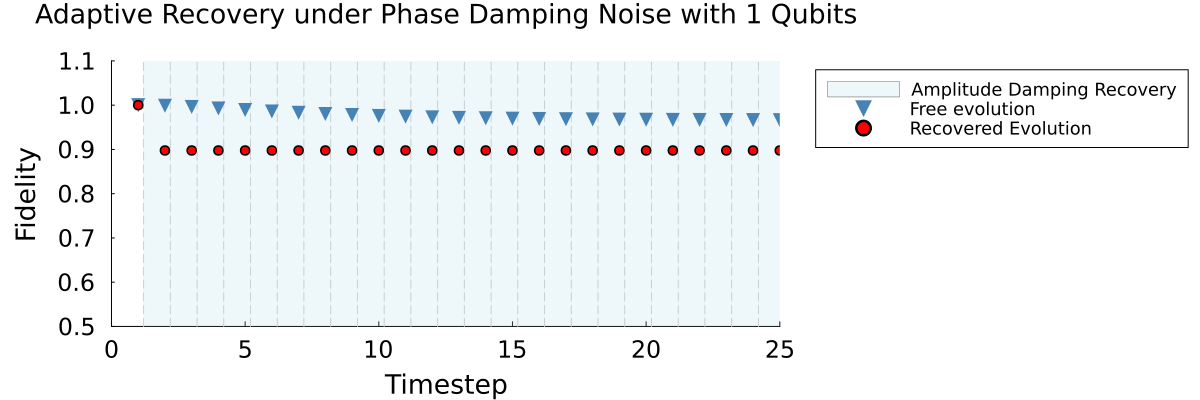

In [ ]:
g1 = plot_autorecovery(
  st, cfg, lgs; 
  xlims=[0, 25],
  ylims=[0.5, 1.1],
  show=false
  )

In [ ]:
function save_results!(cfg::RecoveryConfig, state::RecoveryState, logs::RecoveryLogs, avg_fidelities)

  function _serialize_maps(logs::RecoveryLogs)
    return [
        Dict(
            "Nx" => vec(real(m.Nx)),
            "N1" => vec(real(m.N1)),
            "N2" => vec(real(m.N2)),
            "P" => vec(real(m.P)),
            "dim" => size(m.Nx)
        ) for m in logs.maps
    ]
  end

  out_file = joinpath(cfg.experiment_dir, "data", "results.json")
  payload = Dict(
      "timestamp" => string(now()),
      "experiment" => cfg.name,
      "n_qubits" => cfg.n_qubits,
      "n_timesteps" => cfg.n_timesteps,
      "n_states" => cfg.n_states,
      "seed" => cfg.seed,
      "real_noise" => cfg.real_noise.name,
      "noise_options" => [n.name for n in state.noise_options],
      "fidelities" => logs.fidelities,
      "ref_fidelities" => logs.ref_fidelities,
      "choice_history" => state.choice.history,
      "choice_c1" => state.choice.c1,
      "choice_c2" => state.choice.c2,
      "avg_ref_fidelities" => avg_fidelities[1],
      "avg_fidelities" => avg_fidelities[2],
      "maps" => _serialize_maps(logs)
  )

  open(out_file, "w") do io
      JSON.print(io, payload, 2)
  end
  return out_file
end

save_results!(cfg, st, lgs, (lgs.ref_fidelities, lgs.fidelities))

"/home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/experiments/notebook/data/results.json"

In [ ]:
ks1 = get_kraus_operators("amplitude_damping", 0.2, 1.0)
ks2 = get_kraus_operators("bitflip", 0.6, 1.0)

kraus_to_superop(ks2) - kraus_to_superop(ks1)

4×4 Matrix{ComplexF64}:
 -0.225594+0.0im        0.0+0.0im        0.0+0.0im   0.0443249+0.0im
       0.0+0.0im  -0.130432+0.0im   0.225594+0.0im         0.0+0.0im
       0.0+0.0im   0.225594+0.0im  -0.130432+0.0im         0.0+0.0im
  0.225594+0.0im        0.0+0.0im        0.0+0.0im  -0.0443249+0.0im

In [ ]:
display(latexify(cfg.real_noise.supermap; fmt="%.3f"))
display(latexify(st.noise_options[1].supermap_noise; fmt="%.5f"))
display(latexify(st.noise_options[2].supermap_noise; fmt="%.5f"))

L"\begin{equation}
\left[
\begin{array}{cccc}
0.600+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.600+0.000\mathit{i} \\
0.400+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.400+0.000\mathit{i} \\
0.400+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.400+0.000\mathit{i} \\
0.400+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.400+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
1.00000+0.00000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.18127+0.00000\mathit{i} \\
0.0\mathit{i} & 0.90484+0.00000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.90484+0.00000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.81873+0.00000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
1.00000+0.00000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.81873+0.00000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.81873+0.00000\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 1.00000+0.00000\mathit{i} \\
\end{array}
\right]
\end{equation}
"